# Redes Neuronales II — Notebook 01
## Perceptrón, red de una capa y red multicapa con *backpropagation* (NumPy)

**Objetivo.** Implementar desde cero, sólo con NumPy, los tres modelos base del curso y la mecánica que los hace aprender:

1. Funciones de activación (Escalón, Sigmoide, Tanh, ReLU, Softmax) y sus derivadas.
2. **Perceptrón de Rosenblatt** (regla de aprendizaje del perceptrón).
3. **Red neuronal de una capa** (neurona sigmoide entrenada por descenso de gradiente sobre entropía cruzada).
4. **Red neuronal multicapa (MLP)** entrenada con **backpropagation**, con verificación numérica del gradiente (*gradient checking*).

Se usan los problemas lógicos AND / OR / XOR y el dataset sintético `make_moons` para visualizar fronteras de decisión.

> Ejecutable en Google Colab: `Entorno de ejecución → Ejecutar todas`. No requiere GPU.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
os.makedirs("figures", exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
print("NumPy", np.__version__)

NumPy 2.4.4


## 1. Funciones de activación

| Función | Definición | Derivada | Rango |
|---|---|---|---|
| Escalón | $H(z)=1$ si $z\ge 0$, si no $0$ | 0 (no diferenciable en 0) | {0, 1} |
| Sigmoide | $\sigma(z)=\dfrac{1}{1+e^{-z}}$ | $\sigma(z)(1-\sigma(z))$ | (0, 1) |
| Tanh | $\tanh(z)$ | $1-\tanh^2(z)$ | (−1, 1) |
| ReLU | $\max(0,z)$ | 1 si $z>0$, si no 0 | [0, ∞) |
| Softmax | $\dfrac{e^{z_k}}{\sum_j e^{z_j}}$ | $s_k(\delta_{kj}-s_j)$ | (0,1), suma 1 |

La derivada es lo que usa backpropagation. El escalón tiene derivada nula en casi todo punto, por eso **no** sirve para descenso de gradiente y el perceptrón usa una regla de actualización propia.

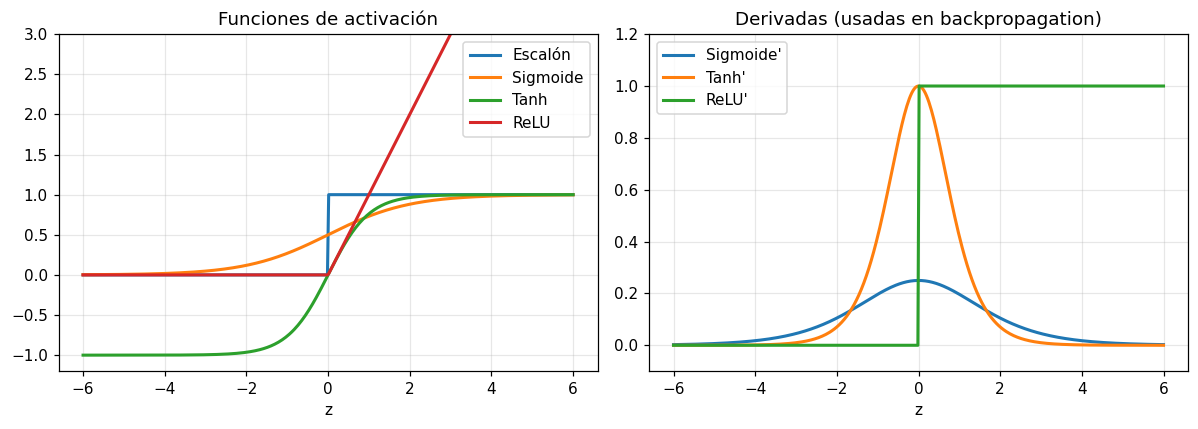

Máximo de σ'(z) = 0.25  → con 10 capas sigmoides el gradiente puede reducirse ~0.25^10 = 9.5e-07
softmax([2,1,0.1]) = [[0.659 0.242 0.099]] (suma 1)


In [2]:
def step(z):        return (z >= 0).astype(float)
def sigmoid(z):     return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
def d_sigmoid(z):   s = sigmoid(z); return s * (1 - s)
def tanh(z):        return np.tanh(z)
def d_tanh(z):      return 1 - np.tanh(z) ** 2
def relu(z):        return np.maximum(0, z)
def d_relu(z):      return (z > 0).astype(float)
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))   # estabilidad numérica
    return e / e.sum(axis=1, keepdims=True)

ACTIVATIONS = {"sigmoid": (sigmoid, d_sigmoid), "tanh": (tanh, d_tanh), "relu": (relu, d_relu)}

z = np.linspace(-6, 6, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, f, df in [("Escalón", step, None), ("Sigmoide", sigmoid, d_sigmoid),
                    ("Tanh", tanh, d_tanh), ("ReLU", relu, d_relu)]:
    axes[0].plot(z, f(z), label=name, lw=2)
    if df is not None:
        axes[1].plot(z, df(z), label=f"{name}'", lw=2)
axes[0].set_title("Funciones de activación"); axes[0].set_ylim(-1.2, 3); axes[0].legend()
axes[1].set_title("Derivadas (usadas en backpropagation)"); axes[1].set_ylim(-0.1, 1.2); axes[1].legend()
for a in axes: a.set_xlabel("z")
plt.tight_layout(); plt.savefig("figures/01_activaciones.png", bbox_inches="tight"); plt.show()

print(f"Máximo de σ'(z) = {d_sigmoid(np.array([0.0]))[0]:.2f}  → con 10 capas sigmoides el gradiente puede reducirse ~0.25^10 = {0.25**10:.1e}")
print("softmax([2,1,0.1]) =", softmax(np.array([[2.0, 1.0, 0.1]])).round(3), "(suma 1)")

**Observación.** La derivada de la sigmoide nunca supera 0.25: al encadenar capas el gradiente se multiplica por factores < 1 y se **desvanece**. ReLU tiene derivada 1 en la zona activa, por eso es la activación oculta por defecto en redes profundas. La sigmoide se mantiene en la **salida** de clasificación binaria porque produce una probabilidad.

## 2. Perceptrón de Rosenblatt

Salida: $\hat y = H(\mathbf{w}^\top\mathbf{x} + b)$. Regla de aprendizaje, para cada muestra mal clasificada:

$$\mathbf{w} \leftarrow \mathbf{w} + \eta\,(y-\hat y)\,\mathbf{x}, \qquad b \leftarrow b + \eta\,(y-\hat y)$$

El teorema de convergencia garantiza que termina si los datos son **linealmente separables**.

In [3]:
class Perceptron:
    """Perceptrón de Rosenblatt con activación escalón."""
    def __init__(self, lr=0.1, epochs=50, seed=SEED):
        self.lr, self.epochs, self.rng = lr, epochs, np.random.default_rng(seed)

    def fit(self, X, y):
        self.w = self.rng.normal(0, 0.01, X.shape[1]); self.b = 0.0
        self.errors_ = []
        for _ in range(self.epochs):
            errors = 0
            for i in self.rng.permutation(len(X)):
                update = self.lr * (y[i] - self.predict(X[i:i+1])[0])
                self.w += update * X[i]; self.b += update
                errors += int(update != 0)
            self.errors_.append(errors)
            if errors == 0:          # convergió
                break
        return self

    def decision_function(self, X): return X @ self.w + self.b
    def predict(self, X):           return step(self.decision_function(X))
    def score(self, X, y):          return (self.predict(X) == y).mean()

X_logic = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
TABLES = {"AND": np.array([0, 0, 0, 1.]), "OR": np.array([0, 1, 1, 1.]), "XOR": np.array([0, 1, 1, 0.])}

for gate, y in TABLES.items():
    p = Perceptron(lr=0.1, epochs=100).fit(X_logic, y)
    print(f"{gate:>3}: predicción={p.predict(X_logic).astype(int)}  real={y.astype(int)}  "
          f"exactitud={p.score(X_logic, y):.2f}  épocas={len(p.errors_)}")

AND: predicción=[0 0 0 1]  real=[0 0 0 1]  exactitud=1.00  épocas=5
 OR: predicción=[0 1 1 1]  real=[0 1 1 1]  exactitud=1.00  épocas=4
XOR: predicción=[0 0 0 0]  real=[0 1 1 0]  exactitud=0.50  épocas=100


AND y OR convergen en pocas épocas; **XOR no converge**: no existe una recta que separe (0,1),(1,0) de (0,0),(1,1). Esta es la limitación clásica (Minsky & Papert, 1969) que motiva las capas ocultas.

## 3. Red neuronal de una capa (neurona sigmoide)

Se reemplaza el escalón por la sigmoide, lo que hace el modelo diferenciable, y se minimiza la **entropía cruzada binaria**:

$$\mathcal{L} = -\frac{1}{m}\sum_{i}\big[y_i\log \hat y_i + (1-y_i)\log(1-\hat y_i)\big], \qquad \hat y = \sigma(\mathbf{X}\mathbf{w}+b)$$

Su gradiente tiene una forma compacta: $\dfrac{\partial\mathcal{L}}{\partial \mathbf{w}} = \dfrac{1}{m}\mathbf{X}^\top(\hat{\mathbf{y}}-\mathbf{y})$. Es el caso de backpropagation con **una sola capa**.

In [4]:
class SingleLayerNet:
    """Red de una capa: una neurona sigmoide + entropía cruzada + descenso de gradiente (batch)."""
    def __init__(self, lr=0.5, epochs=2000, l2=0.0, seed=SEED):
        self.lr, self.epochs, self.l2, self.rng = lr, epochs, l2, np.random.default_rng(seed)

    def fit(self, X, y):
        m = len(X)
        self.w = self.rng.normal(0, 0.01, X.shape[1]); self.b = 0.0
        self.loss_ = []
        for _ in range(self.epochs):
            p = sigmoid(X @ self.w + self.b)                     # forward
            self.loss_.append(bce(y, p) + 0.5 * self.l2 * np.sum(self.w**2) / m)
            dz = (p - y) / m                                      # backward
            self.w -= self.lr * (X.T @ dz + self.l2 * self.w / m)
            self.b -= self.lr * dz.sum()
        return self

    def predict_proba(self, X): return sigmoid(X @ self.w + self.b)
    def predict(self, X):       return (self.predict_proba(X) >= 0.5).astype(float)
    def score(self, X, y):      return (self.predict(X) == y).mean()

def bce(y, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

for gate, y in TABLES.items():
    s = SingleLayerNet(lr=1.0, epochs=3000).fit(X_logic, y)
    print(f"{gate:>3}: p(y=1)={s.predict_proba(X_logic).round(2)}  exactitud={s.score(X_logic, y):.2f}  pérdida final={s.loss_[-1]:.3f}")

AND: p(y=1)=[0.   0.01 0.01 0.99]  exactitud=1.00  pérdida final=0.006


 OR: p(y=1)=[0.01 1.   1.   1.  ]  exactitud=1.00  pérdida final=0.003


XOR: p(y=1)=[0.5 0.5 0.5 0.5]  exactitud=0.50  pérdida final=0.693


La red de una capa resuelve AND/OR con probabilidades bien calibradas, pero en XOR la pérdida se estanca en $\ln 2 \approx 0.693$ (predice 0.5 para todo): sigue siendo un **clasificador lineal**.

## 4. Red multicapa (MLP) con backpropagation

Para una red de $L$ capas, con $\mathbf{Z}^{[l]} = \mathbf{A}^{[l-1]}\mathbf{W}^{[l]} + \mathbf{b}^{[l]}$ y $\mathbf{A}^{[l]} = g^{[l]}(\mathbf{Z}^{[l]})$:

**Paso hacia adelante (forward):** se calculan y guardan $\mathbf{Z}^{[l]}, \mathbf{A}^{[l]}$ para cada capa.

**Paso hacia atrás (backward), regla de la cadena:**

$$\delta^{[L]} = \mathbf{A}^{[L]} - \mathbf{Y} \quad\text{(sigmoide+BCE o softmax+CE)}$$
$$\frac{\partial\mathcal{L}}{\partial \mathbf{W}^{[l]}} = \frac{1}{m}\,\mathbf{A}^{[l-1]\top}\delta^{[l]}, \qquad \frac{\partial\mathcal{L}}{\partial \mathbf{b}^{[l]}} = \frac{1}{m}\sum_i \delta^{[l]}_i$$
$$\delta^{[l-1]} = \big(\delta^{[l]}\,\mathbf{W}^{[l]\top}\big)\odot g'^{[l-1]}(\mathbf{Z}^{[l-1]})$$

**Actualización** (SGD con *momentum* y regularización L2): $\mathbf{v} \leftarrow \beta\mathbf{v} - \eta\,\nabla\mathbf{W}$, $\;\mathbf{W}\leftarrow\mathbf{W}+\mathbf{v}$.

Mejoras respecto a la versión básica: inicialización **He** (ReLU) / **Xavier** (sigmoide/tanh), mini-lotes, momentum, L2 y registro de historial de entrenamiento/validación.

In [5]:
class MLP:
    """Perceptrón multicapa en NumPy con backpropagation.

    layers: p. ej. [n_features, 16, 8, 1]. Salida sigmoide si la última capa tiene 1 neurona
    (clasificación binaria), softmax si tiene >1 (multiclase).
    """
    def __init__(self, layers, hidden="relu", lr=0.05, epochs=500, batch_size=32,
                 momentum=0.9, l2=0.0, seed=SEED, verbose=0):
        self.layers, self.hidden = layers, hidden
        self.g, self.dg = ACTIVATIONS[hidden]
        self.lr, self.epochs, self.bs = lr, epochs, batch_size
        self.beta, self.l2, self.verbose = momentum, l2, verbose
        self.rng = np.random.default_rng(seed)
        self.binary = layers[-1] == 1
        self._init_params()

    def _init_params(self):
        self.W, self.b = [], []
        for n_in, n_out in zip(self.layers[:-1], self.layers[1:]):
            scale = np.sqrt(2.0 / n_in) if self.hidden == "relu" else np.sqrt(1.0 / n_in)  # He / Xavier
            self.W.append(self.rng.normal(0, scale, (n_in, n_out)))
            self.b.append(np.zeros((1, n_out)))
        self.vW = [np.zeros_like(w) for w in self.W]
        self.vb = [np.zeros_like(b) for b in self.b]

    # ---------- forward ----------
    def forward(self, X):
        A, cache = X, [(None, X)]
        for l, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A @ W + b
            last = l == len(self.W) - 1
            A = (sigmoid(Z) if self.binary else softmax(Z)) if last else self.g(Z)
            cache.append((Z, A))
        return A, cache

    def loss(self, Y, A):
        data = bce(Y, A) if self.binary else -np.mean(np.sum(Y * np.log(np.clip(A, 1e-12, 1)), axis=1))
        reg = 0.5 * self.l2 * sum(np.sum(W**2) for W in self.W) / len(Y)
        return data + reg

    # ---------- backward ----------
    def backward(self, Y, cache):
        m = len(Y)
        gW, gb = [None] * len(self.W), [None] * len(self.W)
        delta = cache[-1][1] - Y                                   # δ^[L]
        for l in reversed(range(len(self.W))):
            A_prev = cache[l][1]
            gW[l] = A_prev.T @ delta / m + self.l2 * self.W[l] / m
            gb[l] = delta.sum(axis=0, keepdims=True) / m
            if l > 0:
                delta = (delta @ self.W[l].T) * self.dg(cache[l][0])  # δ^[l-1]
        return gW, gb

    def _step(self, gW, gb):
        for l in range(len(self.W)):
            self.vW[l] = self.beta * self.vW[l] - self.lr * gW[l]; self.W[l] += self.vW[l]
            self.vb[l] = self.beta * self.vb[l] - self.lr * gb[l]; self.b[l] += self.vb[l]

    def _prep_y(self, y):
        y = np.asarray(y)
        if self.binary: return y.reshape(-1, 1).astype(float)
        return np.eye(self.layers[-1])[y.astype(int)]

    def fit(self, X, y, X_val=None, y_val=None):
        Y = self._prep_y(y)
        self.history = {"loss": [], "acc": [], "val_loss": [], "val_acc": []}
        for ep in range(self.epochs):
            idx = self.rng.permutation(len(X))
            for s in range(0, len(X), self.bs):
                bi = idx[s:s + self.bs]
                A, cache = self.forward(X[bi])
                self._step(*self.backward(Y[bi], cache))
            A, _ = self.forward(X)
            self.history["loss"].append(self.loss(Y, A)); self.history["acc"].append(self.score(X, y))
            if X_val is not None:
                Av, _ = self.forward(X_val)
                self.history["val_loss"].append(self.loss(self._prep_y(y_val), Av))
                self.history["val_acc"].append(self.score(X_val, y_val))
            if self.verbose and (ep + 1) % self.verbose == 0:
                msg = f"época {ep+1:4d} | pérdida {self.history['loss'][-1]:.4f} | acc {self.history['acc'][-1]:.3f}"
                if X_val is not None: msg += f" | val_pérdida {self.history['val_loss'][-1]:.4f} | val_acc {self.history['val_acc'][-1]:.3f}"
                print(msg)
        return self

    def predict_proba(self, X): return self.forward(X)[0]
    def predict(self, X):
        A = self.predict_proba(X)
        return (A[:, 0] >= 0.5).astype(float) if self.binary else A.argmax(axis=1)
    def score(self, X, y): return (self.predict(X) == np.asarray(y)).mean()

### 4.1 Verificación del gradiente (*gradient checking*)

Para comprobar que backpropagation está bien implementado se compara el gradiente analítico con la aproximación por diferencias centrales $\dfrac{\mathcal{L}(\theta+\varepsilon)-\mathcal{L}(\theta-\varepsilon)}{2\varepsilon}$. Una diferencia relativa < $10^{-7}$ indica una implementación correcta.

In [6]:
def gradient_check(net, X, y, eps=1e-5):
    Y = net._prep_y(y)
    _, cache = net.forward(X)
    gW, _ = net.backward(Y, cache)
    analytic, numeric = [], []
    for l, W in enumerate(net.W):
        for idx in np.ndindex(W.shape):
            old = W[idx]
            W[idx] = old + eps; lp = net.loss(Y, net.forward(X)[0])
            W[idx] = old - eps; lm = net.loss(Y, net.forward(X)[0])
            W[idx] = old
            numeric.append((lp - lm) / (2 * eps)); analytic.append(gW[l][idx])
    a, n = np.array(analytic), np.array(numeric)
    return np.linalg.norm(a - n) / (np.linalg.norm(a) + np.linalg.norm(n))

rng = np.random.default_rng(0)
Xg = rng.normal(size=(20, 3))
for hidden in ["sigmoid", "tanh", "relu"]:
    net_b = MLP([3, 5, 4, 1], hidden=hidden, l2=0.1); yb = rng.integers(0, 2, 20)
    net_m = MLP([3, 5, 4, 3], hidden=hidden, l2=0.1); ym = rng.integers(0, 3, 20)
    print(f"{hidden:>7} | binaria: {gradient_check(net_b, Xg, yb):.2e} | multiclase (softmax): {gradient_check(net_m, Xg, ym):.2e}")

sigmoid | binaria: 8.95e-11 | multiclase (softmax): 1.15e-10
   tanh | binaria: 7.01e-11 | multiclase (softmax): 1.85e-10
   relu | binaria: 3.77e-11 | multiclase (softmax): 5.59e-11


Las diferencias relativas están en el orden de $10^{-9}$–$10^{-11}$: **el gradiente de backpropagation coincide con el numérico** para las tres activaciones y ambos tipos de salida.

### 4.2 El MLP resuelve XOR

XOR → p(y=1) = [0.002 0.995 0.997 0.006] | exactitud = 1.0


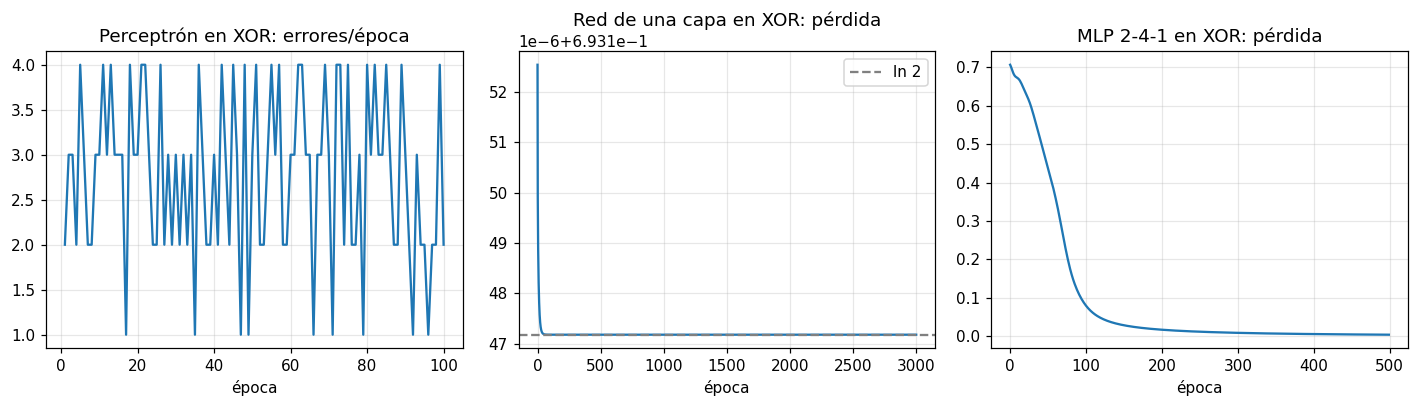

In [7]:
xor = MLP([2, 4, 1], hidden="tanh", lr=0.1, epochs=500, batch_size=4, momentum=0.9).fit(X_logic, TABLES["XOR"])
print("XOR → p(y=1) =", xor.predict_proba(X_logic).ravel().round(3), "| exactitud =", xor.score(X_logic, TABLES["XOR"]))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
per = Perceptron(epochs=100).fit(X_logic, TABLES["XOR"])
axes[0].plot(np.arange(1, len(per.errors_) + 1), per.errors_); axes[0].set_title("Perceptrón en XOR: errores/época")
sln = SingleLayerNet(lr=1.0, epochs=3000).fit(X_logic, TABLES["XOR"])
axes[1].plot(sln.loss_); axes[1].axhline(np.log(2), ls="--", c="gray", label="ln 2"); axes[1].legend()
axes[1].set_title("Red de una capa en XOR: pérdida")
axes[2].plot(xor.history["loss"]); axes[2].set_title("MLP 2-4-1 en XOR: pérdida")
for a in axes: a.set_xlabel("época")
plt.tight_layout(); plt.savefig("figures/01_xor_convergencia.png", bbox_inches="tight"); plt.show()

## 5. Comparación en un problema no lineal: `make_moons`

Se comparan los tres modelos y, dentro del MLP, las activaciones ocultas **Sigmoide vs ReLU** con la misma arquitectura (2-16-16-1).

Perceptrón             exactitud train=0.883  test=0.867
Una capa (sigmoide)    exactitud train=0.871  test=0.867
MLP oculta Sigmoide    exactitud train=0.962  test=0.967
MLP oculta ReLU        exactitud train=0.964  test=0.978


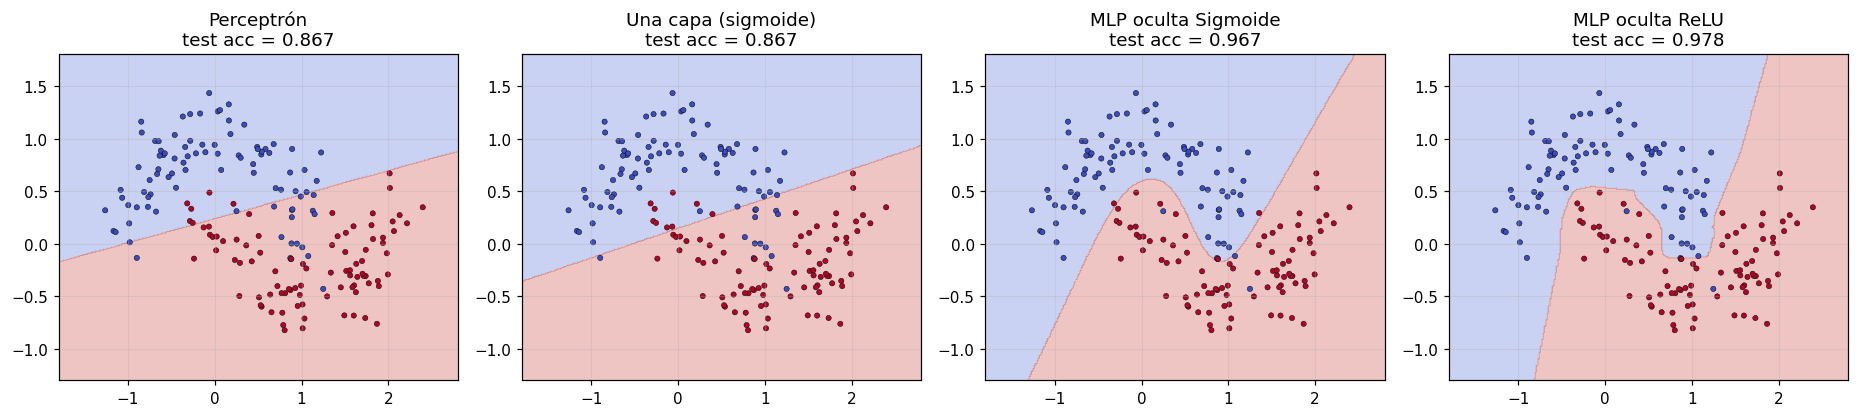

In [8]:
Xm, ym = make_moons(n_samples=600, noise=0.2, random_state=SEED)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.3, random_state=SEED, stratify=ym)

models = {
    "Perceptrón": Perceptron(lr=0.1, epochs=100).fit(Xm_tr, ym_tr),
    "Una capa (sigmoide)": SingleLayerNet(lr=0.5, epochs=2000).fit(Xm_tr, ym_tr),
    "MLP oculta Sigmoide": MLP([2, 16, 16, 1], hidden="sigmoid", lr=0.05, epochs=300).fit(Xm_tr, ym_tr, Xm_te, ym_te),
    "MLP oculta ReLU": MLP([2, 16, 16, 1], hidden="relu", lr=0.05, epochs=300).fit(Xm_tr, ym_tr, Xm_te, ym_te),
}
for name, mdl in models.items():
    print(f"{name:<22} exactitud train={mdl.score(Xm_tr, ym_tr):.3f}  test={mdl.score(Xm_te, ym_te):.3f}")

xx, yy = np.meshgrid(np.linspace(-1.8, 2.8, 300), np.linspace(-1.3, 1.8, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
fig, axes = plt.subplots(1, 4, figsize=(17, 3.9))
for a, (name, mdl) in zip(axes, models.items()):
    a.contourf(xx, yy, mdl.predict(grid).reshape(xx.shape), alpha=0.3, cmap="coolwarm")
    a.scatter(Xm_te[:, 0], Xm_te[:, 1], c=ym_te, cmap="coolwarm", s=12, edgecolor="k", lw=0.3)
    a.set_title(f"{name}\ntest acc = {mdl.score(Xm_te, ym_te):.3f}")
plt.tight_layout(); plt.savefig("figures/01_fronteras_moons.png", bbox_inches="tight"); plt.show()

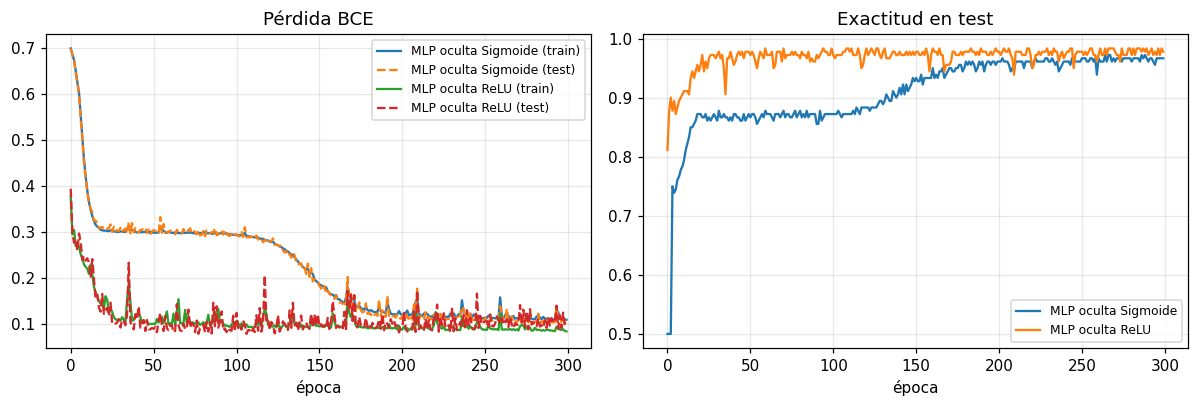

MLP oculta Sigmoide: primera época con val_acc ≥ 0.95 → 161
MLP oculta ReLU: primera época con val_acc ≥ 0.95 → 19


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for name in ["MLP oculta Sigmoide", "MLP oculta ReLU"]:
    h = models[name].history
    ax[0].plot(h["loss"], label=f"{name} (train)"); ax[0].plot(h["val_loss"], "--", label=f"{name} (test)")
    ax[1].plot(h["val_acc"], label=name)
ax[0].set_title("Pérdida BCE"); ax[1].set_title("Exactitud en test"); ax[0].legend(fontsize=8); ax[1].legend(fontsize=8)
for a in ax: a.set_xlabel("época")
plt.tight_layout(); plt.savefig("figures/01_sigmoide_vs_relu.png", bbox_inches="tight"); plt.show()
for name in ["MLP oculta Sigmoide", "MLP oculta ReLU"]:
    h = models[name].history
    first = next((i + 1 for i, v in enumerate(h["val_acc"]) if v >= 0.95), None)
    print(f"{name}: primera época con val_acc ≥ 0.95 → {first}")

## 6. Conclusiones

* El **perceptrón** y la **red de una capa** son clasificadores lineales: resuelven AND/OR pero fallan en XOR y en `make_moons` (frontera recta).
* Añadir capas ocultas con activación no lineal permite fronteras curvas; el **MLP** resuelve XOR y separa las lunas con > 95 % de exactitud.
* **Backpropagation** se verificó numéricamente (error relativo ~$10^{-10}$).
* Con la misma arquitectura, **ReLU converge más rápido que Sigmoide** porque su derivada no satura; la sigmoide se reserva para la salida binaria.